# Data preparation: Load data with DuckDB

In [65]:
import duckdb
import logging

#setting up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler("bats_analysis.log"),
        logging.StreamHandler()
    ]
)

# connect to database
try:
    con = duckdb.connect("../data/bats.db")
    logging.info("Connected to DuckDB database.")
except Exception as e:
    logging.error(f"Failed to connect to database: {e}")
    raise

# read csv tables in
tables = {
    "bot": "../data/bats_bottle.csv",
    "pp": "../data/bats_primary_productivity.csv",
    "pig": "../data/bats_pigments.csv",
    "ctd": "../data/bats_ctd.csv"
}
for table_name, path in tables.items():
    try:
        con.execute(f"CREATE OR REPLACE TABLE {table_name} AS SELECT * FROM read_csv_auto('{path}');")
        logging.info(f"Table '{table_name}' successfully created from {path}.")
    except Exception as e:
        logging.error(f"Failed to create table '{table_name}': {e}")
        raise

# Check tables
try:
    logging.info(f"Current tables: {con.execute('SHOW TABLES').fetchall()}")
except Exception as e:
    logging.error(f"Failed to show tables: {e}")


2026-03-30 20:03:13,022 [INFO] Connected to DuckDB database.
2026-03-30 20:03:13,943 [INFO] Table 'bot' successfully created from ../data/bats_bottle.csv.
2026-03-30 20:03:14,091 [INFO] Table 'pp' successfully created from ../data/bats_primary_productivity.csv.
2026-03-30 20:03:14,238 [INFO] Table 'pig' successfully created from ../data/bats_pigments.csv.
2026-03-30 20:03:24,715 [INFO] Table 'ctd' successfully created from ../data/bats_ctd.csv.
2026-03-30 20:03:24,768 [INFO] Current tables: [('bot',), ('bot_clean',), ('bottle',), ('ctd',), ('ctd_clean',), ('merged',), ('pig',), ('pig_clean',), ('pigments',), ('pp',), ('pp_clean',), ('primary_productivity',)]


In [66]:
# clean tables
try:
    con.execute("""
    CREATE OR REPLACE TABLE pp_clean AS
    SELECT
        ID,
        Cruise_num,
        CAST(Date AS DATE) AS date,
        Depth,
        Pressure,
        pp
    FROM pp;
    """)
    logging.info("Cleaned table 'pp_clean'.")
except Exception as e:
    logging.error(f"Failed to clean 'pp': {e}")

try:
    con.execute("""
    CREATE OR REPLACE TABLE bot_clean AS
    SELECT
        Cruise_num,
        Depth,
        Temperature,
        Salinity,
        PO4,
        PON,
        TOC,
        TN,
        POP,
        TDP
    FROM bot;
    """)
    logging.info("Cleaned table 'bot_clean'.")
except Exception as e:
    logging.error(f"Failed to clean 'bot': {e}")

try:
    con.execute("""
    CREATE OR REPLACE TABLE pig_clean AS
    SELECT
        Cruise_num,
        Depth,
        p1, p2, p3, p14, p16_Chl
    FROM pig;
    """)
    logging.info("Cleaned table 'pig_clean'.")
except Exception as e:
    logging.error(f"Failed to clean 'pig': {e}")

try:
    con.execute("""
    CREATE OR REPLACE TABLE ctd_clean AS
    SELECT
        Cruise_num,
        Depth,
        Oxygen,
        BAC,
        Flu,
        PAR
    FROM ctd;
    """)
    logging.info("Cleaned table 'ctd_clean'.")
except Exception as e:
    logging.error(f"Failed to clean 'ctd': {e}")


2026-03-30 20:04:38,330 [INFO] Cleaned table 'pp_clean'.
2026-03-30 20:04:38,515 [INFO] Cleaned table 'bot_clean'.
2026-03-30 20:04:38,527 [INFO] Cleaned table 'pig_clean'.
2026-03-30 20:04:40,587 [INFO] Cleaned table 'ctd_clean'.


In [67]:
# merge
try:
    con.execute("""
    CREATE OR REPLACE TABLE merged AS
    SELECT
        pp.ID,
        pp.date,
        pp.Depth,
        pp.Pressure,
        pp.pp,
        bot.Temperature,
        bot.Salinity,
        bot.PO4,
        bot.PON,
        bot.TOC,
        bot.TN,
        bot.POP,
        bot.TDP,
        pig.p1,
        pig.p2,
        pig.p3,
        pig.p14,
        pig.p16_Chl,
        ctd.Oxygen,
        ctd.BAC,
        ctd.Flu,
        ctd.PAR
    FROM pp_clean pp
    LEFT JOIN bot_clean bot
        ON pp.Cruise_num = bot.Cruise_num
        AND ROUND(pp.Depth, 1) = ROUND(bot.Depth, 1)
    LEFT JOIN pig_clean pig
        ON pp.Cruise_num = pig.Cruise_num
        AND ROUND(pp.Depth, 1) = ROUND(pig.Depth, 1)
    LEFT JOIN ctd_clean ctd
        ON pp.Cruise_num = ctd.Cruise_num
        AND ROUND(pp.Depth, 1) = ROUND(ctd.Depth, 1);
    """)
    logging.info("Merged table successfully created.")
except Exception as e:
    logging.error(f"Failed to merge tables: {e}")

2026-03-30 20:05:15,619 [INFO] Merged table successfully created.


# Queries to prepare solution

In [ ]:
# data retained after merging
df = con.execute("""
SELECT COUNT(*) AS total_rows,
       COUNT(pp) AS non_null_pp,
       COUNT(Temperature) AS bottle_data,
       COUNT(p1) AS pigment_data,
       COUNT(Oxygen) AS ctd_data
FROM merged;
""").fetchdf()
print(df)

# average primary productivity by depth
df = con.execute("""
SELECT 
    ROUND(Depth, 0) AS depth_bin,
    AVG(pp) AS avg_pp,
    COUNT(*) AS n
FROM merged
GROUP BY depth_bin
ORDER BY depth_bin;
""").fetchdf()
print(df)

# relationship between temperature and primary productivity
df = con.execute("""
SELECT 
    Temperature,
    pp
FROM merged
WHERE Temperature IS NOT NULL AND pp IS NOT NULL
LIMIT 1000;
""").fetchdf()
print(df.head())

   total_rows  non_null_pp  bottle_data  pigment_data  ctd_data
0        7439         7371         5247           466      2903
    depth_bin     avg_pp    n
0         0.0   6.055000    2
1         1.0   6.711111  245
2         2.0  10.978333    6
3         3.0   6.296744  143
4         4.0   6.380996  284
..        ...        ...  ...
76      143.0  -0.172000   30
77      144.0   0.250000    2
78      145.0  -0.050000    1
79      146.0   0.630000    1
80      161.0   0.136667    3

[81 rows x 3 columns]
   Temperature    pp
0       19.411  0.07
1       19.411  0.07
2       19.411  0.07
3       18.944  0.01
4       18.944  0.01


# Analysis

2026-03-30 20:09:56,746 [INFO] Merged CSV successfully read into pandas.


XGB R²: 0.642
RMSE: 2.422
MAE: 1.794


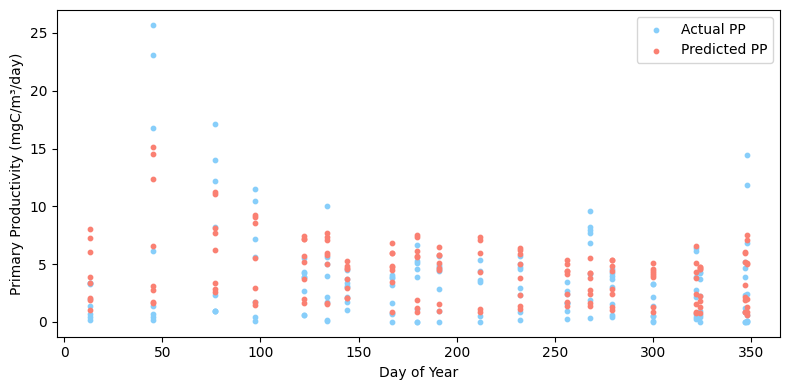

In [71]:
# importing packages
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# read in data
try:
    orig_df = pd.read_csv('../data/bats_merged.csv')
    logging.info("Merged CSV successfully read into pandas.")
except Exception as e:
    logging.error(f"Failed to read merged CSV: {e}")
    raise
#reformatting columns
orig_df = orig_df.apply(pd.to_numeric, errors='coerce').astype('float64')
# converting yymmdd to date time
orig_df['yymmdd'] = pd.to_datetime(orig_df['yymmdd_in'], format='%Y%m%d') #convert to date time
# adding a day of year column
orig_df['day_of_year'] = orig_df['yymmdd'].dt.dayofyear # day out of 365
# renaming variables
orig_df['PP'] = orig_df['pp']
orig_df['TON'] = orig_df['TN']
orig_df['TOP'] = orig_df['TDP']
orig_df['BAC'] = orig_df['Bact']

# choosing features
df = orig_df[["yymmdd", "day_of_year", "Depth", "Chl", "Temp", "Sal", "O2", "NO3", "PO4", "POC", "PON", "POP", "TOC", "TON", "TOP", "BAC", "PP"]].copy()
#Adding additional columns to help with pp seasonality 
# extracting year, month, day
df['year'] = df['yymmdd'].dt.year           
df['month'] = df['yymmdd'].dt.month         
df['day'] = df['yymmdd'].dt.day           
# feature engineering
df["sin_doy"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["cos_doy"] = np.cos(2 * np.pi * df["day_of_year"] / 365)
#convert all negative pp values to 0
df.loc[df['PP'] < 0, 'PP'] = 0
#drop nans
df = df.dropna()

# XGBoost model
X = df.drop(columns = ['PP', "yymmdd"])  # predictors, drop target and datetime variable
Y = df['PP'] # target
#forecasting split
test_size = int(0.15 * len(df))
X_train, X_test = X[:-test_size], X[-test_size:]
Y_train, Y_test = Y[:-test_size], Y[-test_size:]
# create model
xgb_mod = xgb.XGBRegressor(n_estimators = 200, learning_rate = 0.01, max_depth = 7, min_child_weight = 5, subsample = 0.6, colsample_bytree = 0.8, gamma = 0, random_state = 42, eval_metric="rmse")
xgb_mod.fit( X_train, Y_train, verbose=False)
# predict
Y_pred = xgb_mod.predict(X_test)

# evaluate w a couple metrics
rmse = math.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
print(f"XGB R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

#Plot predictions 
fig, axs = plt.subplots(figsize=(8, 4))
# Scatter plot for actual PP values
axs.scatter(df.loc[Y_test.index, 'day_of_year'], Y_test, color='lightskyblue', label='Actual PP', s=10)
axs.scatter(df.loc[Y_test.index, 'day_of_year'], Y_pred, color='salmon', label='Predicted PP', s=10)
axs.set_xlabel('Day of Year')
axs.set_ylabel('Primary Productivity (mgC/m³/day)')
axs.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

Analysis rationale: 

The goal of this analysis was to predict primary productviity using environmental predictors like temperature, salinity, nutrients, etc. I split the dataset into a 85/15% split, with the first 85% going to the training set and the last 15% going to the test set. This way, I could replicate forecasting conditions. I chose an XGBoost regresison model since it can handle complex data and patterns and is generally suitable for tabular data. I evaluated model performance with 3 main metrics - r^2, rmse, and mae. This allowed me to get a more well rounded evaluation of variability and accuracy in the model predictions. We saw a r^2 score of 0.64, rmse of 2.42, and mae of 1.79, which suggests we can predict primary productivity values relatively well. 

Visualization rationale:

This figure visualizes the actual primary productivity values vs the predicted primary productivity values. These are data points from the test set, and I chose to set the x axis as day of year (instead of over time) to see if there were any patterns in seasonality. The y axis shows primary productivity in its original units, which allows us to see how much error there is in the predictions. With an R^2 of 0.64, we can see that the model does a pretty good job but there is room for improvement. Through the visualization, we can see that the model is generally underpredicting the higher values and overpredicting the lower values. 